In [ ]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import scipy.stats as stats
Planet_data= pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv', comment='#')
from scipy import constants
k_b = constants.physical_constants['Boltzmann constant'][0]  
h = constants.physical_constants['Planck constant'][0]
c= constants.physical_constants['speed of light in vacuum'][0]                                                 
planet_name= 'GJ 1214 b'

: 

In [60]:
R_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_rad'].values[0] * 6.96e8 #m (convert solar radii to meters)
print(np.sqrt(0.0011* R_star**2))

4990697.786536869


In [ ]:
#--- the flux of photons at the planet's location ---#

R_p = Planet_data[Planet_data['pl_name'] == planet_name]['pl_rade'].values[0] * 6371 * 10**3 #m
T_eq = Planet_data[Planet_data['pl_name'] == planet_name]['pl_Teq'].values[0]
labmda_range= np.linspace(4.245 * 10**(-6),4.27 * 10**(-6), 1000) #m
T_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_teff'].values[0]
R_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_rad'].values[0] * 6.96e8 #m (convert solar radii to meters)
a= Planet_data[Planet_data['pl_name'] == planet_name]['pl_orbsmax'].values[0] * 1.496e+11 #m
print(f"Star temp: {T_star} K, Star radius: {R_star/6.96e8:.3f} R_sun, Orbital distance: {a/1.496e11:.3f} AU")
# Planck function: B_lambda = (2*h*c^2/lambda^5) * 1/(exp(h*c/(lambda*k_b*T)) - 1)
planck_function = (2 * h * c**2 / labmda_range**5) * (1 / (np.exp(h * c / (labmda_range * k_b * T_star)) - 1))
# Geometric factor: (R_star/a)^2
geometric_factor = (R_star / a)**2
# Spectral flux at planet (W/m^2/m)
flux_lambda = geometric_factor * planck_function
# Convert to photon flux (photons/m^2/s/m) by dividing by energy per photon (E = h*c/lambda)
photon_flux_lambda = flux_lambda * labmda_range / (h * c)
# Integrate over wavelength (trapezoid rule)
d_lambda = labmda_range[1] - labmda_range[0]
flux_total_photons = np.trapezoid(photon_flux_lambda, dx=d_lambda)
print(f"Photon flux: {flux_total_photons:.3e} photons/m^2/s")

: 

CO2 scale height: 8.86 km
Bulk atmosphere scale height: 73.55 km

At 1100 km:
  Total pressure: 3.197e-02 Pa
  CO2 mixing ratio: 3.732e-48
  CO2 partial pressure: 1.193e-49 Pa
  CO2 fraction of total density: 1.347e-55 per km


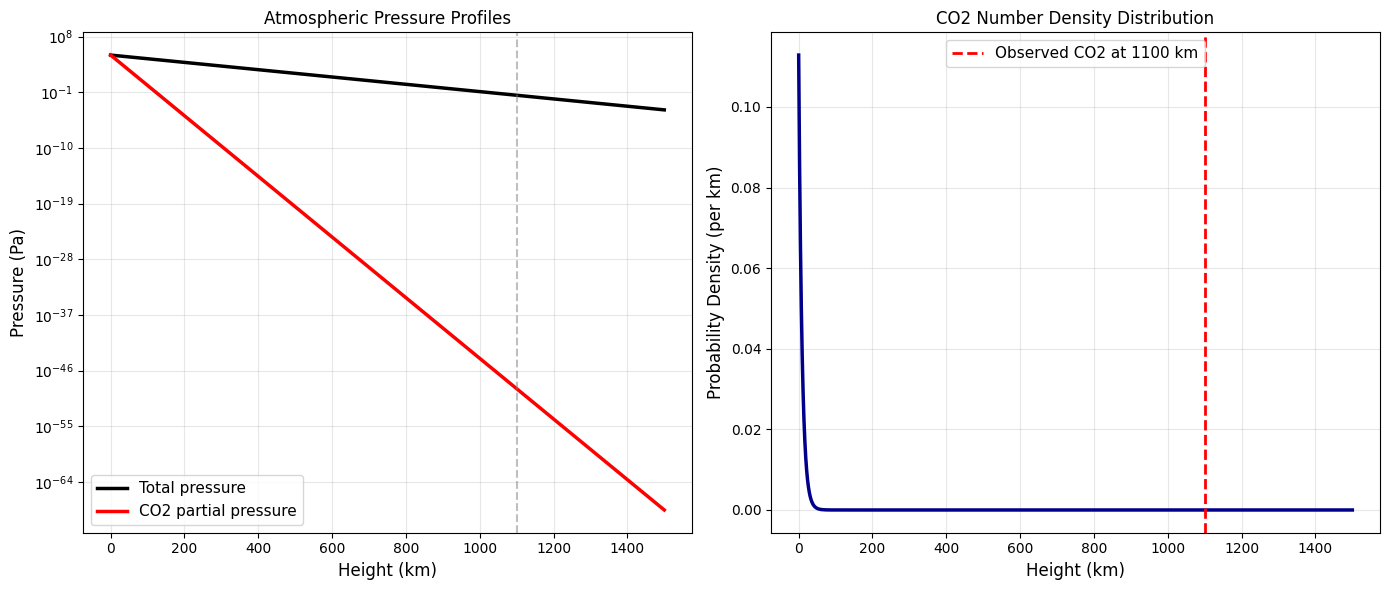

In [ ]:
#-- CO2 Number density and Pressure at different heights --#
#-- Using exponential barometric formula: n(z) ∝ exp(-m*g*z / k_B*T) --#

# CO2 parameters
m_CO2 = 44 * constants.atomic_mass #kg
T_eq = Planet_data[Planet_data['pl_name'] == planet_name]['pl_Teq'].values[0]
g = Planet_data[Planet_data['pl_name'] == planet_name]['g_planet_cgs'].values[0] / 100

# Bulk atmosphere parameters (for total pressure calculation)
m_bulk = 5.3 * constants.atomic_mass #kg (mean molecular mass)

# Calculate scale heights
H_CO2 = (k_b * T_eq) / (m_CO2 * g)
H_bulk = (k_b * T_eq) / (m_bulk * g)
print(f"CO2 scale height: {H_CO2/1000:.2f} km")
print(f"Bulk atmosphere scale height: {H_bulk/1000:.2f} km")

# Assume surface pressure of 1 bar
P_surface = 1e5  # Pa (1 bar)

# Height array
height = np.linspace(0, 1500e3, 10000)

# CO2 number density profile (normalized to total)
n_CO2_unnormalized = np.exp(-height / H_CO2)
d_height = height[1] - height[0]
total_CO2 = np.trapezoid(n_CO2_unnormalized, dx=d_height)
n_CO2 = n_CO2_unnormalized / total_CO2

# Total atmospheric pressure at height z
P_total = P_surface * np.exp(-height / H_bulk)

# CO2 mixing ratio (using separate scale heights)
mixing_ratio = np.exp(-height / H_CO2) / np.exp(-height / H_bulk)

# CO2 partial pressure
P_CO2 = P_total * mixing_ratio

# CO2 number density in m^-3 using ideal gas law: n = P / (k_B * T)
n_CO2_m3 = P_CO2 / (k_b * T_eq)

print(f"\nAt 1100 km:")
idx_1100 = np.argmin(np.abs(height - 1100e3))
print(f"  Total pressure: {P_total[idx_1100]:.3e} Pa")
print(f"  CO2 mixing ratio: {mixing_ratio[idx_1100]:.3e}")
print(f"  CO2 partial pressure: {P_CO2[idx_1100]:.3e} Pa")
print(f"  CO2 number density: {n_CO2_m3[idx_1100]:.3e} m^-3")

# Plot 1: Total and CO2 partial pressure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.semilogy(height/1000, P_total, linewidth=2.5, label='Total pressure', color='black')
ax1.semilogy(height/1000, P_CO2, linewidth=2.5, label='CO2 partial pressure', color='red')
ax1.axvline(1100, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Height (km)', fontsize=12)
ax1.set_ylabel('Pressure (Pa)', fontsize=12)
ax1.set_title('Atmospheric Pressure Profiles', fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=11)

# Plot 2: CO2 number density
ax2.semilogy(height/1000, n_CO2_m3, linewidth=2.5, color='darkblue')
ax2.axvline(1100, color='r', linestyle='--', linewidth=2, label='Observed CO2 at 1100 km')
ax2.set_xlabel('Height (km)', fontsize=12)
ax2.set_ylabel('CO2 Number Density (m$^{-3}$)', fontsize=12)
ax2.set_title(f'CO2 Number Density Distribution', fontsize=12)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#--- the flux of photons at the planet's location ---#

R_p = Planet_data[Planet_data['pl_name'] == planet_name]['pl_rade'].values[0] * 6371 * 10**3 #m
T_eq = Planet_data[Planet_data['pl_name'] == planet_name]['pl_Teq'].values[0]
labmda_range= np.linspace(4.245 * 10**(-6),4.27 * 10**(-6), 1000) #m
T_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_teff'].values[0]
R_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_rad'].values[0] * 6.96e8 #m (convert solar radii to meters)
a= Planet_data[Planet_data['pl_name'] == planet_name]['pl_orbsmax'].values[0] * 1.496e+11 #m
print(f"Star temp: {T_star} K, Star radius: {R_star/6.96e8:.3f} R_sun, Orbital distance: {a/1.496e11:.3f} AU")
# Planck function: B_lambda = (2*h*c^2/lambda^5) * 1/(exp(h*c/(lambda*k_b*T)) - 1)
planck_function = (2 * h * c**2 / labmda_range**5) * (1 / (np.exp(h * c / (labmda_range * k_b * T_star)) - 1))
# Geometric factor: (R_star/a)^2
geometric_factor = (R_star / a)**2
# Spectral flux at planet (W/m^2/m)
flux_lambda = geometric_factor * planck_function
# Convert to photon flux (photons/m^2/s/m) by dividing by energy per photon (E = h*c/lambda)
photon_flux_lambda = flux_lambda * labmda_range / (h * c)
# Integrate over wavelength (trapezoid rule)
d_lambda = labmda_range[1] - labmda_range[0]
flux_total_photons = np.trapezoid(photon_flux_lambda, dx=d_lambda)
print(f"Photon flux: {flux_total_photons:.3e} photons/m^2/s")

: 

Gravity: 11.06 m/s^2
Scale height: 8.86 km = 8859.80 m
Max height: 88.60 km
P_H range after normalization: 0.000e+00 to 5.464e-05
Integral check (should be ~1): 1.000000


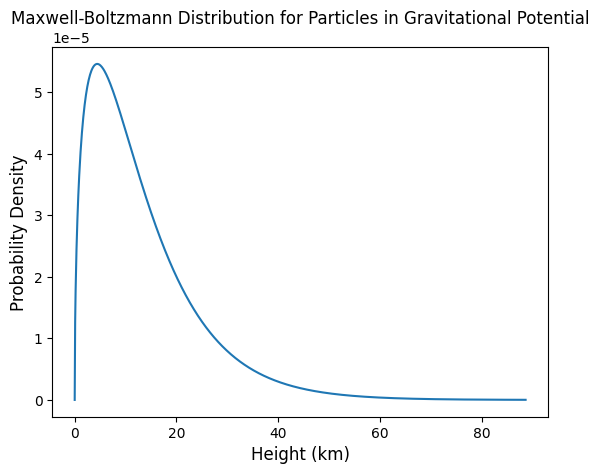

In [65]:
#-- Probability density of particle at a given height (Maxwell-Boltzmann energy distribution) --#
#-- Setting energy E = mgh (gravitational potential energy) --#

m = 44 * constants.atomic_mass #kg (mass of carbon atom, as an example)
T_eq = Planet_data[Planet_data['pl_name'] == planet_name]['pl_Teq'].values[0] # kelvin
g = Planet_data[Planet_data['pl_name'] == planet_name]['g_planet_cgs'].values[0] / 100 # m/s^2 (convert from cm/s^2)

# Calculate scale height to diagnose the issue
H_scale = (k_b * T_eq) / (m * g)
print(f"Gravity: {g:.2f} m/s^2")
print(f"Scale height: {H_scale/1000:.2f} km = {H_scale:.2f} m")
# Use height range from 0 to 5 scale heights
height = np.linspace(0, 10 * H_scale, 1000)
print(f"Max height: {height[-1]/1000:.2f} km")
# Maxwell-Boltzmann: P(E) ∝ sqrt(E) * exp(-E/k_B*T), with E = mgh
exponent = -m * g * height / (k_b * T_eq)
P_H_unnormalized = 2 * np.sqrt(m * g * height / np.pi) * (k_b * T_eq)**(-3/2) * np.exp(exponent)
# Normalize so integral = 1
d_height = height[1] - height[0]
integral = np.trapezoid(P_H_unnormalized, dx=d_height)
P_H = P_H_unnormalized / integral
print(f"P_H range after normalization: {P_H.min():.3e} to {P_H.max():.3e}")
print(f"Integral check (should be ~1): {np.trapezoid(P_H, dx=d_height):.6f}")

plt.plot(height/1000, P_H)
plt.xlabel('Height (km)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Maxwell-Boltzmann Distribution for Particles in Gravitational Potential', fontsize=12)
plt.show()

PearsonRResult(statistic=np.float64(-0.2983569665422522), pvalue=np.float64(0.00013354560813904972))
0.0


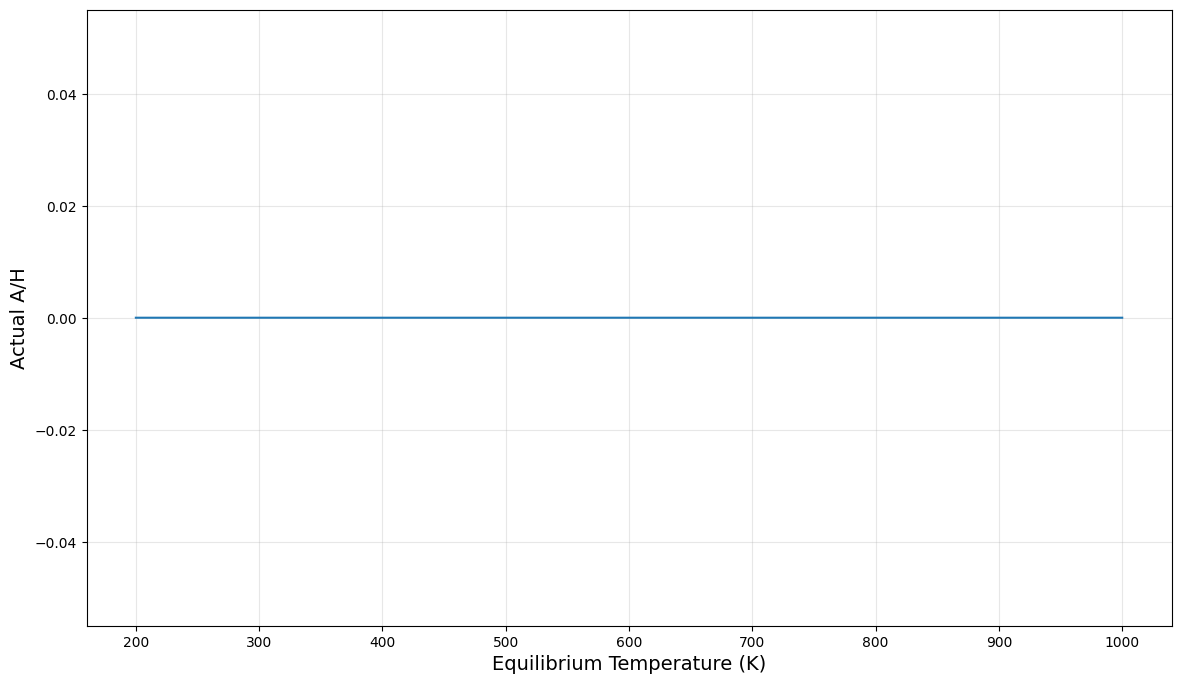

In [ ]:
Actual_values = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')
Actual_A_H = Actual_values['A/H']
T_eq= Actual_values['pl_Teq']
R= stats.pearsonr(T_eq, Actual_A_H)
print(R)
Teq= np.arange(200, 1000, 0.01)
function= (1/(k_b * Teq))**(3/2) * (np.exp(-1/(k_b * Teq))) 
print(function[0])
plt.figure(figsize=(14,8))
plt.plot(Teq, function, label='Function of T_eq')
#plt.scatter(T_eq, Actual_A_H, label='Actual A/H')
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('Actual A/H', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

PearsonRResult(statistic=np.float64(-0.2983569665422522), pvalue=np.float64(0.00013354560813904972))
0.0


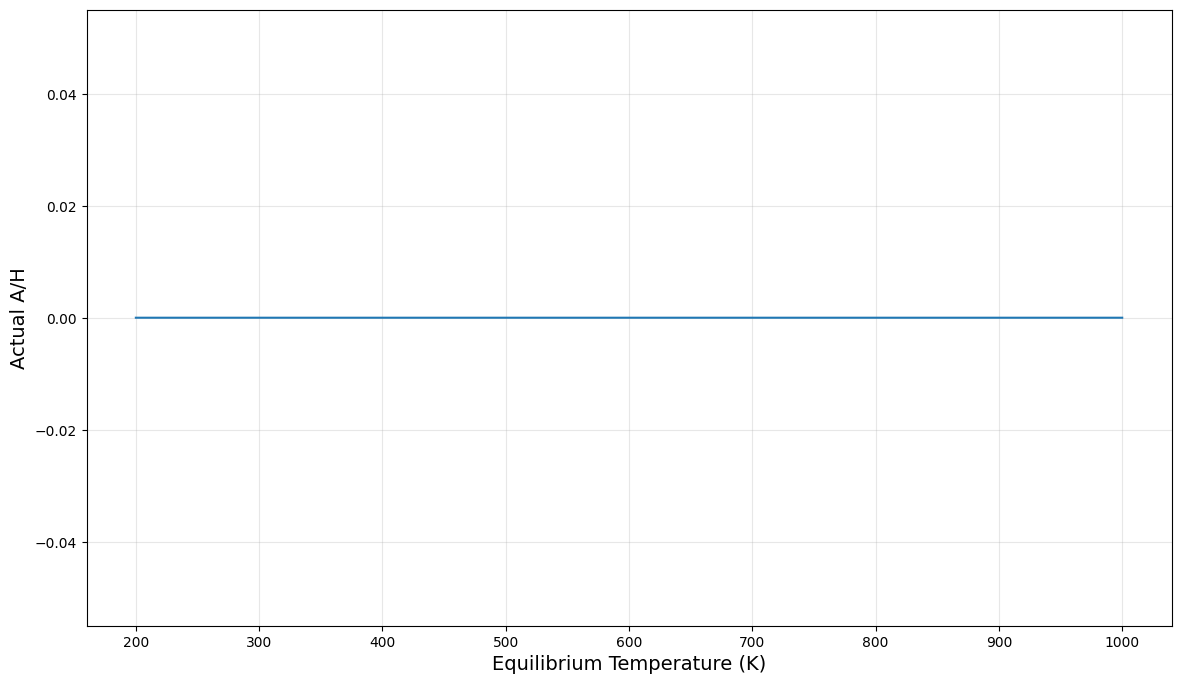

In [ ]:
Actual_values = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')
Actual_A_H = Actual_values['A/H']
T_eq= Actual_values['pl_Teq']
R= stats.pearsonr(T_eq, Actual_A_H)
print(R)
Teq= np.arange(200, 1000, 0.01)
function= (1/(k_b * Teq))**(3/2) * (np.exp(-1/(k_b * Teq))) 
print(function[0])
plt.figure(figsize=(14,8))
plt.plot(Teq, function, label='Function of T_eq')
#plt.scatter(T_eq, Actual_A_H, label='Actual A/H')
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('Actual A/H', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

In [ ]:
R_star = Planet_data[Planet_data['pl_name'] == planet_name]['st_rad'].values[0] * 6.96e8 #m (convert solar radii to meters)
R_p = Planet_data[Planet_data['pl_name'] == planet_name]['pl_rade'].values[0] * 6371 * 10**3 #m
dell = 0.01497046100888632
h= np.sqrt((dell- R_p**2/R_star**2)* R_star**2)
print(f'h = {h/1000} km')
Actual_values = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')
print(Actual_values[Actual_values['pl_name'] == planet_name]['A/H'])


h = 5983.074723030922 km
2    14.667374
Name: A/H, dtype: float64
